In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

# 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 봄

In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist손글씨 데이터셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩 (pd.getdummies)
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU
from matplotlib import pyplot as plt
# train_test_split등을 추가

In [3]:
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [4]:
print('타겟변수 :', data[15,0])
image = data[15, 1:].reshape(28,28)
image.shape

타겟변수 : 7.0


(28, 28)

In [5]:
for row in image:
    for pixel in row:
        print(f"{pixel:3.0f}", end='')
    print()# 개행

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0115121162253253213  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 63107170251252252252252250214  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 25192226226241252253202252252252252252225  0  0  0  0  0  0
  0  0  0  0  0  0  0 68223252252252252252 39 19 39 65224252252183  0  0  0  0  0  0
  0  0  0  0  0  0  0186252252252245108 53  0  0  0150252252220 2

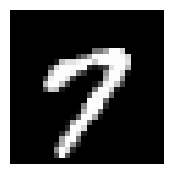

In [6]:
plt.rcParams['figure.figsize']=(2,2)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [7]:
# 칼라사진 -> 흑백모드로 넘파이배열로 읽기(pip install opencv-python==4.8.1.78)

In [8]:
%pip install opencv-python==4.8.1.78

Note: you may need to restart the kernel to use updated packages.


In [9]:
import cv2
# 사진이미지를 흑백포맷으로 넘파이배열로 읽어오기
image_array = cv2.imread('data/sample.jpg', cv2.IMREAD_GRAYSCALE)
image_array.shape, type(image_array)

((408, 612), numpy.ndarray)

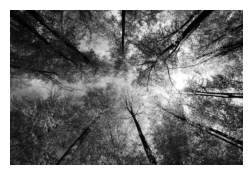

In [10]:
plt.figure(figsize=(3,4))
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.show()

# 1. 데이터 생성 및 전처리

In [11]:
(X_train, y_train),(X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [12]:
value, counts = np.unique(y_train, return_counts=True)
ratios = counts/y_train.shape[0]
dict(zip(value, ratios))

{0: 0.09871666666666666,
 1: 0.11236666666666667,
 2: 0.0993,
 3: 0.10218333333333333,
 4: 0.09736666666666667,
 5: 0.09035,
 6: 0.09863333333333334,
 7: 0.10441666666666667,
 8: 0.09751666666666667,
 9: 0.09915}

In [13]:
value, counts = np.unique(y_test, return_counts=True)
ratios = counts/y_test.shape[0]
dict(zip(value, ratios))

{0: 0.098,
 1: 0.1135,
 2: 0.1032,
 3: 0.101,
 4: 0.0982,
 5: 0.0892,
 6: 0.0958,
 7: 0.1028,
 8: 0.0974,
 9: 0.1009}

2


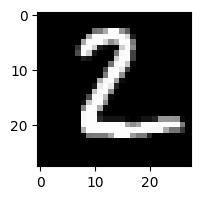

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0116125171255255150 93  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0169253253253253253253218 30  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0169253253253213142176253253122  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 52250253210 32 12  0  6206253140  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 77251210 25  0  0  0122248253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 31 18  0  0  0  0209253253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0117247253198 10  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 76247253231 63  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0128253253144  0  0  0  0  0  

In [14]:
print(y_test[1])
plt.imshow(X_test[1], cmap='gray')
plt.show()
for row in X_test[1]:
    for pixel in row:
        print(f"{pixel:3.0f}", end="")
    print()

In [15]:
# Train데이터 6만개 => Train(5만개) + val(만개)로 분리
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [16]:
print('학습셋 :', X_train.shape, y_train.shape)
print('검증셋 :', X_val.shape, y_val.shape)
print('시험셋 :', X_test.shape, y_test.shape)

학습셋 : (50000, 28, 28) (50000,)
검증셋 : (10000, 28, 28) (10000,)
시험셋 : (10000, 28, 28) (10000,)


In [17]:
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [18]:
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

((50000, 10), (10000, 10), (10000, 10))

In [19]:
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
# idx = random.sample(range(50000), 700)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]

In [20]:
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

((700, 784), (700, 10), (300, 784), (300, 10), (10000, 784), (10000, 10))

# 2. 모델 구성
# 3. 학습과정 설정

In [25]:
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))
model.summary()
# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy']) # 평가지표

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 2)                 1570      
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 2)                 0         
                                                                 
 dense_9 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습

In [26]:
%%time
hist = model.fit(train_X, train_Y, # 학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=100,
                epochs=200)

Epoch 1/200
7/7 [==============================] - 1s 54ms/step - loss: 2.3165 - accuracy: 0.0671 - val_loss: 2.3006 - val_accuracy: 0.0633
Epoch 2/200
7/7 [==============================] - 0s 9ms/step - loss: 2.2970 - accuracy: 0.0943 - val_loss: 2.2963 - val_accuracy: 0.1000
Epoch 3/200
7/7 [==============================] - 0s 7ms/step - loss: 2.2894 - accuracy: 0.1271 - val_loss: 2.2870 - val_accuracy: 0.1267
Epoch 4/200
7/7 [==============================] - 0s 9ms/step - loss: 2.2767 - accuracy: 0.1543 - val_loss: 2.2749 - val_accuracy: 0.1600
Epoch 5/200
7/7 [==============================] - 0s 7ms/step - loss: 2.2643 - accuracy: 0.1686 - val_loss: 2.2624 - val_accuracy: 0.1433
Epoch 6/200
7/7 [==============================] - 0s 9ms/step - loss: 2.2503 - accuracy: 0.1800 - val_loss: 2.2507 - val_accuracy: 0.1533
Epoch 7/200
7/7 [==============================] - 0s 7ms/step - loss: 2.2364 - accuracy: 0.1829 - val_loss: 2.2398 - val_accuracy: 0.1500
Epoch 8/200
7/7 [=========

7/7 [==============================] - 0s 8ms/step - loss: 1.6370 - accuracy: 0.3571 - val_loss: 1.6974 - val_accuracy: 0.3600
Epoch 60/200
7/7 [==============================] - 0s 8ms/step - loss: 1.6305 - accuracy: 0.3486 - val_loss: 1.6933 - val_accuracy: 0.3567
Epoch 61/200
7/7 [==============================] - 0s 7ms/step - loss: 1.6242 - accuracy: 0.3500 - val_loss: 1.6892 - val_accuracy: 0.3600
Epoch 62/200
7/7 [==============================] - 0s 10ms/step - loss: 1.6181 - accuracy: 0.3571 - val_loss: 1.6845 - val_accuracy: 0.3567
Epoch 63/200
7/7 [==============================] - 0s 7ms/step - loss: 1.6118 - accuracy: 0.3557 - val_loss: 1.6803 - val_accuracy: 0.3633
Epoch 64/200
7/7 [==============================] - 0s 7ms/step - loss: 1.6058 - accuracy: 0.3657 - val_loss: 1.6772 - val_accuracy: 0.3733
Epoch 65/200
7/7 [==============================] - 0s 7ms/step - loss: 1.5997 - accuracy: 0.3657 - val_loss: 1.6728 - val_accuracy: 0.3767
Epoch 66/200
7/7 [==============

7/7 [==============================] - 0s 8ms/step - loss: 1.3748 - accuracy: 0.4543 - val_loss: 1.5620 - val_accuracy: 0.3933
Epoch 118/200
7/7 [==============================] - 0s 9ms/step - loss: 1.3716 - accuracy: 0.4543 - val_loss: 1.5602 - val_accuracy: 0.3967
Epoch 119/200
7/7 [==============================] - 0s 7ms/step - loss: 1.3687 - accuracy: 0.4529 - val_loss: 1.5601 - val_accuracy: 0.4000
Epoch 120/200
7/7 [==============================] - 0s 7ms/step - loss: 1.3657 - accuracy: 0.4543 - val_loss: 1.5588 - val_accuracy: 0.3900
Epoch 121/200
7/7 [==============================] - 0s 7ms/step - loss: 1.3629 - accuracy: 0.4543 - val_loss: 1.5598 - val_accuracy: 0.4000
Epoch 122/200
7/7 [==============================] - 0s 9ms/step - loss: 1.3595 - accuracy: 0.4586 - val_loss: 1.5575 - val_accuracy: 0.3933
Epoch 123/200
7/7 [==============================] - 0s 10ms/step - loss: 1.3567 - accuracy: 0.4657 - val_loss: 1.5572 - val_accuracy: 0.3933
Epoch 124/200
7/7 [=======

7/7 [==============================] - 0s 7ms/step - loss: 1.2354 - accuracy: 0.5314 - val_loss: 1.5264 - val_accuracy: 0.4100
Epoch 176/200
7/7 [==============================] - 0s 8ms/step - loss: 1.2333 - accuracy: 0.5243 - val_loss: 1.5272 - val_accuracy: 0.4200
Epoch 177/200
7/7 [==============================] - 0s 8ms/step - loss: 1.2314 - accuracy: 0.5214 - val_loss: 1.5273 - val_accuracy: 0.4133
Epoch 178/200
7/7 [==============================] - 0s 9ms/step - loss: 1.2301 - accuracy: 0.5429 - val_loss: 1.5260 - val_accuracy: 0.4167
Epoch 179/200
7/7 [==============================] - 0s 7ms/step - loss: 1.2278 - accuracy: 0.5429 - val_loss: 1.5240 - val_accuracy: 0.4133
Epoch 180/200
7/7 [==============================] - 0s 9ms/step - loss: 1.2264 - accuracy: 0.5257 - val_loss: 1.5274 - val_accuracy: 0.4233
Epoch 181/200
7/7 [==============================] - 0s 9ms/step - loss: 1.2237 - accuracy: 0.5400 - val_loss: 1.5258 - val_accuracy: 0.4133
Epoch 182/200
7/7 [========

# 5. 모델 평가하기

In [27]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

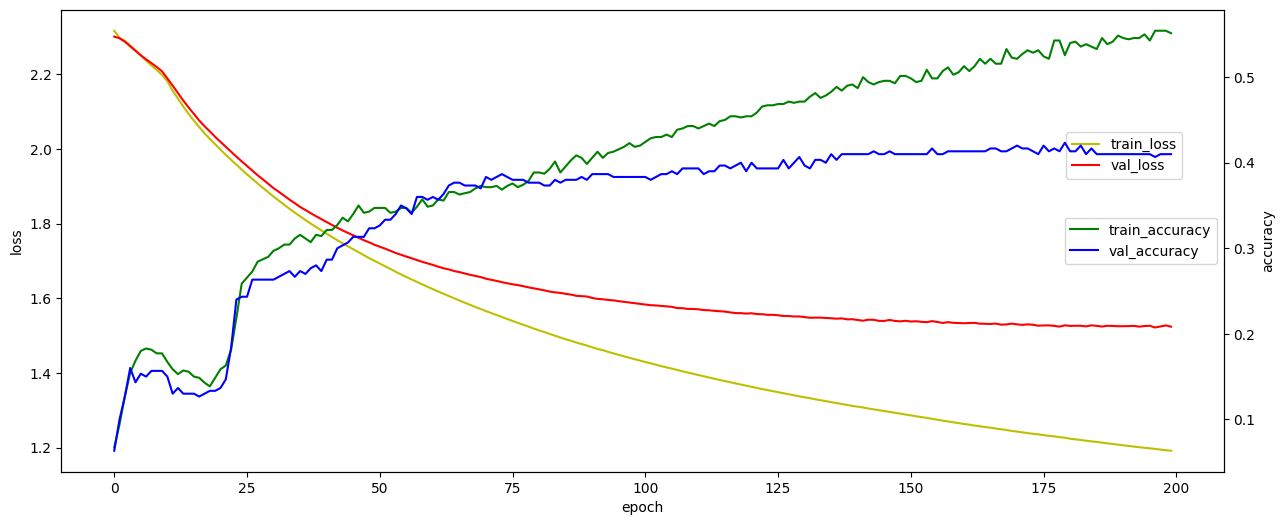

In [28]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97, 0.75))
acc_ax.legend(loc='center right')
plt.show()

In [31]:
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])

loss : 1.539229154586792
accuracy : 0.4180000126361847


# 위 모델(DNN)의 accuracy 늘리기
- 데이터 확보
- 모델 수정(레이어 추가, units수 증가)
- 과적합 방지(validation data추가, 활성화함수를 relu계열, tahn, Dropout추가, 배치정규화, L2정규화(규제)...)
- epoch 조정
- optimizer 변경

In [40]:
%%time
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
# train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
# val_idx   = np.random.choice(10000, 300)
# train_X = train_X[train_idx]
# train_Y = train_Y[train_idx]
# val_X   = val_X[val_idx]
# val_Y   = val_Y[val_idx]
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)
# 모델생성(784->7024->512->128->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=1024))
model.add(BatchNormalization()) # 1024개 출력층을 배치 정규화
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dropout(0.2))

model.add(Dense(units=512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))   
          
model.add(Dense(units=128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1)) 
          
model.add(Dense(units=10, activation='softmax'))
model.summary()
# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 학습
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=30, 
                # verbose=0
                )

(50000, 784) (50000, 10) (10000, 784) (10000, 10) (10000, 784) (10000, 10)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_23 (Dense)            (None, 1024)              803840    
                                                                 
 batch_normalization_3 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 leaky_re_lu_10 (LeakyReLU)  (None, 1024)              0         
                                                                 
 dropout_3 (Dropout)         (None, 1024)              0         
                                                                 
 dense_24 (Dense)            (None, 512)               524800    
                                                                 
 batch_normalization_4 (Batc  (None, 512)      

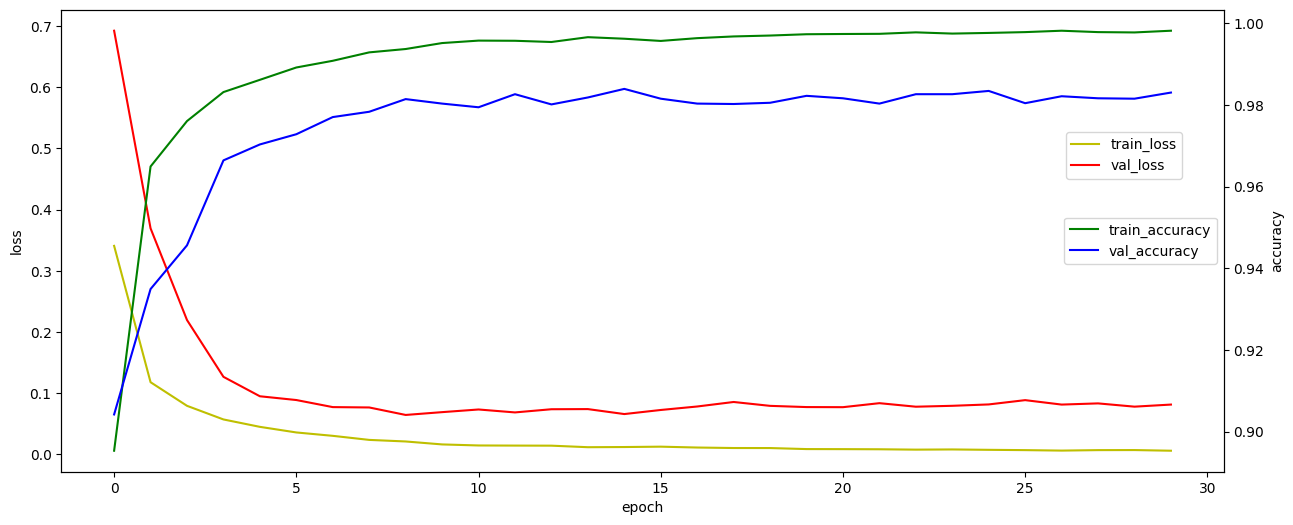

loss : 0.06979598104953766
accuracy : 0.9830999970436096


In [41]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])

In [44]:
# 교차표
y_test # 실제값
test_Y.argmax(axis=1)
np.all(test_Y.argmax(axis=1) == y_test)

True

In [46]:
y_hat = model.predict(test_X).argmax(axis=1) # 예측값
y_hat = np.argmax(model.predict(test_X), axis=1)
y_hat

313/313 [==============================] - 1s 4ms/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [47]:
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,972,0,0,1,0,1,1,1,3,1
1,0,1125,2,1,0,0,3,1,3,0
2,4,1,1014,0,1,0,2,4,5,1
3,0,0,4,994,0,3,0,3,4,2
4,0,0,1,1,957,0,4,1,0,18
5,2,0,0,9,1,871,5,1,2,1
6,3,2,0,0,2,3,947,0,1,0
7,2,3,8,1,1,0,0,1004,7,2
8,2,0,2,3,0,2,0,3,959,3


In [48]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[ 972,    0,    0,    1,    0,    1,    1,    1,    3,    1],
       [   0, 1125,    2,    1,    0,    0,    3,    1,    3,    0],
       [   4,    1, 1014,    0,    1,    0,    2,    4,    5,    1],
       [   0,    0,    4,  994,    0,    3,    0,    3,    4,    2],
       [   0,    0,    1,    1,  957,    0,    4,    1,    0,   18],
       [   2,    0,    0,    9,    1,  871,    5,    1,    2,    1],
       [   3,    2,    0,    0,    2,    3,  947,    0,    1,    0],
       [   2,    3,    8,    1,    1,    0,    0, 1004,    7,    2],
       [   2,    0,    2,    3,    0,    2,    0,    3,  959,    3],
       [   2,    2,    0,    4,    6,    3,    0,    3,    1,  988]],
      dtype=int64)

In [49]:
# 틀린갯수
accuracy = loss_metrics[1]
10000 * accuracy

9830.999970436096

# 콜백함수 1 : 로그출력

In [ ]:
%%time
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)
# 모델생성(784 -> 2 -> 10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
          
model.add(Dense(units=10, activation='softmax'))
model.summary()
# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 학습
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                # verbose=0
                )